# # Scenario Analysis for MCV1 Forecasts
# This notebook evaluates different demographic and policy scenarios on MCV1 forecasts.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict
import warnings
warnings.filterwarnings("ignore")

# Import core forecasting logic
import sys
sys.path.append('.')
from mcv1_forecast.core import train_model, recursive_forecast, COUNTRIES, TARGET

# ## Load Data and Train Base Model

In [9]:
df_raw = pd.read_csv("vaccine_data.csv")
future_demo_df = pd.read_csv("future_demographics.csv")

# Train baseline model
model, df_engineered, feature_cols, _ = train_model(df_raw)

TimeSeries CV MAE Scores: [ 80.41852254 127.72471256 257.22597417]
Average CV MAE: 155.123


# ## Scenario Framework

In [10]:
@dataclass
class Scenario:
    name: str
    description: str
    adjustments: Dict[str, float]
    color: str

class ScenarioEngine:
    def __init__(self, model, df_engineered, feature_cols):
        self.model = model
        self.df_engineered = df_engineered
        self.feature_cols = feature_cols
        
        # Scenarios are instantiated here to avoid mutating a shared class-level dictionary
        self.OPTIMISTIC = Scenario(
            name="Optimistic",
            description="Strong health system, declining mortality, stable births",
            adjustments={
                "Infant Mortality Rate (infant deaths per 1,000 live births)": 0.85,
                "Under-Five Deaths, under age 5 (thousands)": 0.85,
                "Births (thousands)": 1.02,
                "Pop_Age_0(In Thousands)": 1.02,
            },
            color="#2ecc71"
        )
        
        self.PESSIMISTIC = Scenario(
            name="Pessimistic", 
            description="Health system stress, rising mortality, declining coverage",
            adjustments={
                "Infant Mortality Rate (infant deaths per 1,000 live births)": 1.15,
                "Under-Five Deaths, under age 5 (thousands)": 1.15,
                "Births (thousands)": 0.95,
                "Pop_Age_0(In Thousands)": 0.95,
            },
            color="#e74c3c"
        )
        
        # Note on PANDEMIC_SHOCK migration: 
        # By multiplying by 0.3, a negative value (net emigration) becomes less negative,
        # effectively moving migration closer to 0 (halting migration).
        self.PANDEMIC_SHOCK = Scenario(
            name="Pandemic Shock",
            description="COVID-like disruption: coverage drops, migration halts",
            adjustments={
                "Net Number of Migrants (thousands)": 0.3,
                "Net Migration Rate (per 1,000 population)": 0.3,
                "Births (thousands)": 0.97,
                "Pop_Age_0(In Thousands)": 0.97,
            },
            color="#9b59b6"
        )
        
        self.BASELINE = Scenario(
            name="Baseline",
            description="UN medium-variant projections (no adjustment)",
            adjustments={},
            color="#3498db"
        )
        
        self.default_scenarios = [self.BASELINE, self.OPTIMISTIC, self.PESSIMISTIC, self.PANDEMIC_SHOCK]
        
    def apply_scenario(self, demo_df, scenario):
        adjusted_df = demo_df.copy()
        for feature, multiplier in scenario.adjustments.items():
            if feature in adjusted_df.columns:
                # Apply static multiplier. Note: This acts as a constant shock 
                # across all future years and doesn't compound year-over-year.
                # It also adjusts Pop_Age_0 and Births independently as a simplification.
                adjusted_df[feature] *= multiplier
                
                # Prevent biologically impossible negative values for non-migration columns
                if "Migration" not in feature and "Migrants" not in feature:
                    adjusted_df[feature] = adjusted_df[feature].clip(lower=0)
            else:
                warnings.warn(f"Adjustment feature '{feature}' not found in demographics data. Skipping.")
                
        return adjusted_df

    def run_all_scenarios(self, future_demo_df, scenarios=None):
        if scenarios is None:
            scenarios = self.default_scenarios
            
        results = {}
        for scenario in scenarios:
            print(f"Running scenario: {scenario.name}")
            adj_demo_df = self.apply_scenario(future_demo_df, scenario)
            # Run forecast starting from 2025 using adjusted demographics
            pred = recursive_forecast(self.df_engineered, self.model, self.feature_cols, 2025, TARGET, adj_demo_df)
            pred['Scenario'] = scenario.name
            results[scenario.name] = pred
            
        return results, scenarios


# ## Run Scenarios

In [11]:
engine = ScenarioEngine(model, df_engineered, feature_cols)
scenario_results, scenarios_list = engine.run_all_scenarios(future_demo_df)

# Combine all results into one DataFrame for easy analysis
all_results_df = pd.concat(scenario_results.values(), ignore_index=True)

Running scenario: Baseline
Running scenario: Optimistic
Running scenario: Pessimistic
Running scenario: Pandemic Shock


# ## Visualizations

In [12]:
def plot_scenario_dashboard(all_results_df, hist_df, scenarios_list):
    fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(6 * len(COUNTRIES), 5))
    
    # Create color map from scenarios
    color_map = {s.name: s.color for s in scenarios_list}
    
    for i, country in enumerate(COUNTRIES):
        ax = axes[i]
        
        # Plot historical
        country_hist = hist_df[hist_df['Country'] == country]
        ax.plot(country_hist['Year'], country_hist[TARGET], 'ko-', label='Historical', alpha=0.5)
        
        last_hist_year = country_hist['Year'].max()
        last_hist_val = country_hist[TARGET].iloc[-1]
        
        # Plot each scenario
        for scenario in scenarios_list:
            s_data = all_results_df[(all_results_df['Country'] == country) & 
                                    (all_results_df['Scenario'] == scenario.name)]
            
            years = np.insert(s_data['Year'].values, 0, last_hist_year)
            vals = np.insert(s_data['Predicted'].values, 0, last_hist_val)
            
            ax.plot(years, vals, marker='o', color=color_map[scenario.name], 
                    label=scenario.name, linewidth=2)
            
        ax.set_title(f"Scenario Forecast - {country}")
        ax.set_xlabel("Year")
        ax.set_ylabel("MCV1 Target")
        if i == 0:
            ax.legend()
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

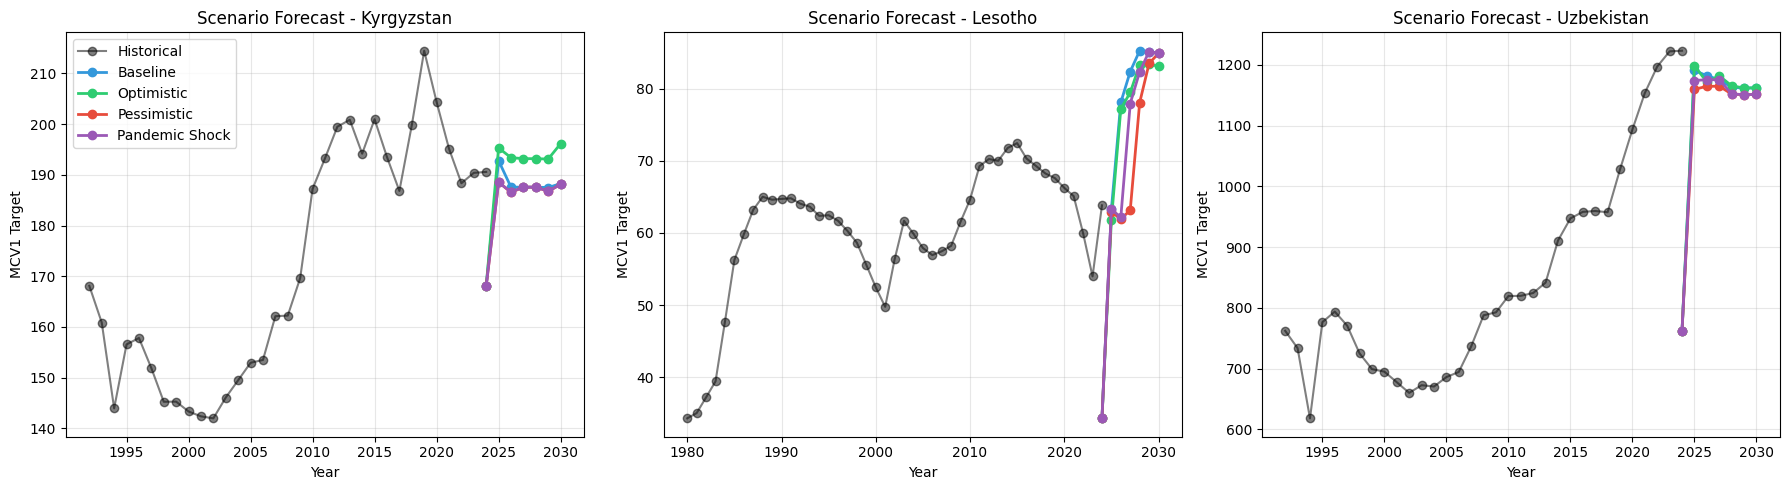

In [13]:
plot_scenario_dashboard(all_results_df, df_raw, scenarios_list)

# ## Comparison Table

In [18]:
from IPython.display import display

In [19]:

# Pivot table to see difference from baseline
baseline = all_results_df[all_results_df['Scenario'] == 'Baseline'].set_index(['Country', 'Year'])['Predicted']
comparison = []

for name, res in scenario_results.items():
    if name == 'Baseline':
        continue
    res_idx = res.set_index(['Country', 'Year'])['Predicted']
    diff = res_idx - baseline
    pct_diff = (diff / baseline) * 100
    
    comp_df = pd.DataFrame({
        'Scenario': name,
        'Absolute Diff': diff,
        '% Diff': pct_diff
    }).reset_index()
    comparison.append(comp_df)

comp_table = pd.concat(comparison, ignore_index=True)
print("Scenario Comparison vs Baseline:")
display(comp_table.groupby(['Country', 'Scenario'])['% Diff'].mean().reset_index().rename(columns={'% Diff': 'Average % Diff'}))

Scenario Comparison vs Baseline:


,Country,Scenario,Average % Diff
0,Kyrgyzstan,Optimistic,2.929453
1,Kyrgyzstan,Pandemic Shock,-0.535915
2,Kyrgyzstan,Pessimistic,-0.536239
3,Lesotho,Optimistic,-2.237779
4,Lesotho,Pandemic Shock,-4.863928
5,Lesotho,Pessimistic,-9.161321
6,Uzbekistan,Optimistic,0.092405
7,Uzbekistan,Pandemic Shock,-0.791703
8,Uzbekistan,Pessimistic,-1.303093
